In [ ]:
# House Price Prediction

This project analyzes housing data and builds a machine learning model to predict house prices.

The workflow includes:
- Data exploration
- Data cleaning
- Feature selection
- Model training
- Model evaluation

In [3]:
#import base di notebook
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score

In [9]:
#carimaneto dataset
df = pd.read_csv(r"C:\Users\Utente\Desktop\house-price-prediction\archive\train.csv")
df.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [ ]:
## Dataset Overview

In [13]:
#numero righe e colonne
df.shape

(1460, 81)

In [15]:
#nomi colonne
df.columns

Index(['Id', 'MSSubClass', 'MSZoning', 'LotFrontage', 'LotArea', 'Street',
       'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig',
       'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType',
       'HouseStyle', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd',
       'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType',
       'MasVnrArea', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual',
       'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinSF1',
       'BsmtFinType2', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', 'Heating',
       'HeatingQC', 'CentralAir', 'Electrical', '1stFlrSF', '2ndFlrSF',
       'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath',
       'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'KitchenQual',
       'TotRmsAbvGrd', 'Functional', 'Fireplaces', 'FireplaceQu', 'GarageType',
       'GarageYrBlt', 'GarageFinish', 'GarageCars', 'GarageArea', 'GarageQual',
       'GarageCond', 'PavedDrive

In [17]:
#tipologie colonne (cat, num) e se ci sono valori null
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

In [29]:
#conta quantità valori null
missing_values = df.isnull().sum().sort_values(ascending=False)
missing_values.head(15)

PoolQC          1453
MiscFeature     1406
Alley           1369
Fence           1179
MasVnrType       872
FireplaceQu      690
LotFrontage      259
GarageYrBlt       81
GarageCond        81
GarageType        81
GarageFinish      81
GarageQual        81
BsmtFinType2      38
BsmtExposure      38
BsmtQual          37
dtype: int64

In [23]:
#media, std, min, max e percentiles
df.describe()

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
count,1460.000000,1460.000000,1201.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1452.000000,1460.000000,...,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,730.500000,56.897260,70.049958,10516.828082,6.099315,5.575342,1971.267808,1984.865753,103.685262,443.639726,...,94.244521,46.660274,21.954110,3.409589,15.060959,2.758904,43.489041,6.321918,2007.815753,180921.195890
std,421.610009,42.300571,24.284752,9981.264932,1.382997,1.112799,30.202904,20.645407,181.066207,456.098091,...,125.338794,66.256028,61.119149,29.317331,55.757415,40.177307,496.123024,2.703626,1.328095,79442.502883
min,1.000000,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,34900.000000
25%,365.750000,20.000000,59.000000,7553.500000,5.000000,5.000000,1954.000000,1967.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,2007.000000,129975.000000
50%,730.500000,50.000000,69.000000,9478.500000,6.000000,5.000000,1973.000000,1994.000000,0.000000,383.500000,...,0.000000,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,163000.000000
75%,1095.250000,70.000000,80.000000,11601.500000,7.000000,6.000000,2000.000000,2004.000000,166.000000,712.250000,...,168.000000,68.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,214000.000000
max,1460.000000,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5644.000000,...,857.000000,547.000000,552.000000,508.000000,480.000000,738.000000,15500.000000,12.000000,2010.000000,755000.000000


In [ ]:
## Target Variable Analysis

In [25]:
df["SalePrice"].describe() 
#per sapere valori base di prezzo di vendita 

count      1460.000000
mean     180921.195890
std       79442.502883
min       34900.000000
25%      129975.000000
50%      163000.000000
75%      214000.000000
max      755000.000000
Name: SalePrice, dtype: float64

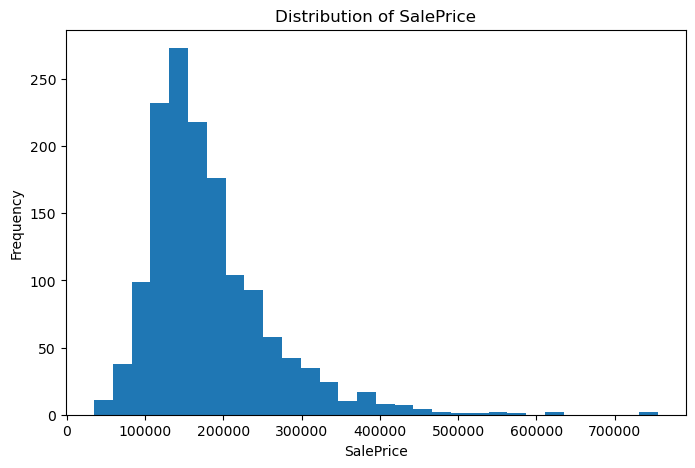

In [27]:
#mostra distribuzione prezzi
plt.figure(figsize=(8,5))
plt.hist(df["SalePrice"], bins=30)
plt.title("Distribution of SalePrice")
plt.xlabel("SalePrice")
plt.ylabel("Frequency")
plt.show()

In [ ]:
## Feature Selection
# scelte alcune variabili numeriche rilevanti per il primo modello predittivo

In [31]:
#creazione dataset ridotto con variabili più utili
selected_columns = [
    "GrLivArea",
    "BedroomAbvGr",
    "FullBath",
    "GarageCars",
    "GarageArea",
    "TotRmsAbvGrd",
    "YearBuilt",
    "SalePrice"
]

data = df[selected_columns]
data.head()

,GrLivArea,BedroomAbvGr,FullBath,GarageCars,GarageArea,TotRmsAbvGrd,YearBuilt,SalePrice
0,1710,3,2,2,548,8,2003,208500
1,1262,3,2,2,460,6,1976,181500
2,1786,3,2,2,608,6,2001,223500
3,1717,3,1,3,642,7,1915,140000
4,2198,4,2,3,836,9,2000,250000


In [ ]:
## Data Cleaning-- null variables cleaning

In [33]:
data.isnull().sum()
# non ci sono null

GrLivArea       0
BedroomAbvGr    0
FullBath        0
GarageCars      0
GarageArea      0
TotRmsAbvGrd    0
YearBuilt       0
SalePrice       0
dtype: int64

In [37]:
#data = data.dropna()
data.shape

(1460, 8)

In [41]:
data = data.dropna()

In [ ]:
## Correlation Analysis
#analisi di correlazione tra variabili

In [45]:
import seaborn as sns

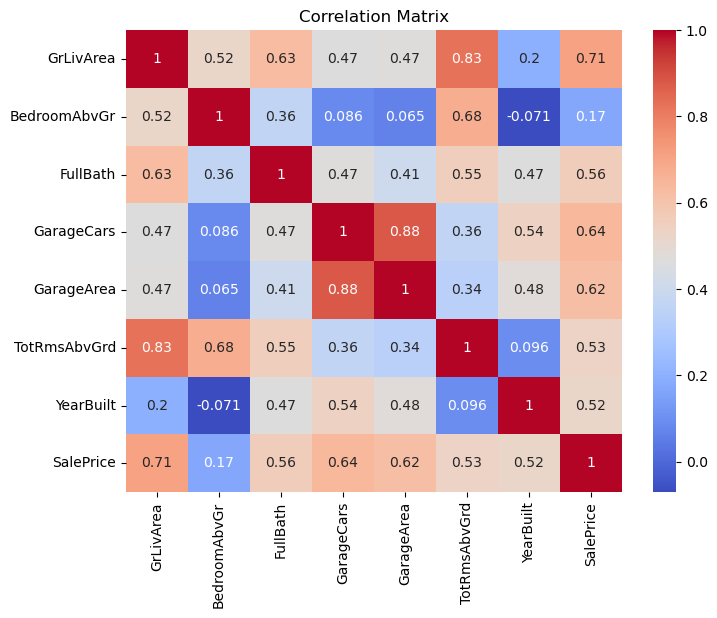

In [47]:
#correlation matrix
plt.figure(figsize=(8,6))
sns.heatmap(data.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

In [ ]:
## Preparing Data for Modeling

In [50]:
X = data.drop("SalePrice", axis=1)
y = data["SalePrice"]
#divide in feature e target variables

In [52]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
#divide dataset in training e test set

In [ ]:
## Linear Regression Model

In [54]:
model = LinearRegression()
model.fit(X_train, y_train)
#addetra modello

LinearRegression()

In [57]:
y_pred = model.predict(X_test)

In [59]:
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("R2:", r2)
#il modello spiega circa il 73% della variabilità nei prezzi delle case
#avarege prediztion error aroun 30.000 which is reasonable considering the simplicity of the model and the limited number of features used.

MAE: 30105.337989279593
R2: 0.7312859395192117


In [61]:
results = pd.DataFrame({
    "Actual Price": y_test,
    "Predicted Price": y_pred
})

results.head(10)
#si vede lo sbaglio di prezzi

,Actual Price,Predicted Price
892,154500,116599.146950
1105,325000,307803.563451
413,115000,117097.660672
522,159000,175396.536492
1036,315500,257810.248522
614,75500,85637.673897
218,311500,201758.627026
1160,146000,181205.694201
649,84500,84145.340174
887,135500,146748.393567


In [ ]:
# new linear regression model

In [83]:
from sklearn.preprocessing import StandardScaler

In [85]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [87]:
model_scaled = LinearRegression()
model_scaled.fit(X_train_scaled, y_train)

y_pred_scaled = model_scaled.predict(X_test_scaled)

mae_scaled = mean_absolute_error(y_test, y_pred_scaled)
r2_scaled = r2_score(y_test, y_pred_scaled)

print("Scaled Linear Regression MAE:", mae_scaled)
print("Scaled Linear Regression R2:", r2_scaled)

Scaled Linear Regression MAE: 30105.33798927968
Scaled Linear Regression R2: 0.7312859395192125


In [ ]:
## Random Forest Model

In [65]:
from sklearn.ensemble import RandomForestRegressor

In [67]:
rf_model = RandomForestRegressor(
    n_estimators=200,
    max_depth=10,
    random_state=42
)

rf_model.fit(X_train, y_train)

RandomForestRegressor(max_depth=10, n_estimators=200, random_state=42)

In [69]:
rf_pred = rf_model.predict(X_test)

In [71]:
rf_mae = mean_absolute_error(y_test, rf_pred)
rf_r2 = r2_score(y_test, rf_pred)

print("Random Forest MAE:", rf_mae)
print("Random Forest R2:", rf_r2)
#MEA and R2 are lower than linear regression

Random Forest MAE: 23268.395957905534
Random Forest R2: 0.8488578029542211


In [91]:
comparison = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Scaled Linear Regression",
        "Random Forest"
    ],
    "MAE": [
        mae,
        mae_scaled,
        rf_mae
    ],
    "R2 Score": [
        r2,
        r2_scaled,
        rf_r2
    ]
})

comparison

,Model,MAE,R2 Score
0,Linear Regression,30105.337989,0.731286
1,Scaled Linear Regression,30105.337989,0.731286
2,Random Forest,23268.395958,0.848858


In [73]:
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
}).sort_values(by="Importance", ascending=False)

feature_importance
#mostra variabili che influenzano di più il prezzo

,Feature,Importance
0,GrLivArea,0.374444
3,GarageCars,0.308119
6,YearBuilt,0.185130
4,GarageArea,0.069503
1,BedroomAbvGr,0.031144
5,TotRmsAbvGrd,0.020205
2,FullBath,0.011456


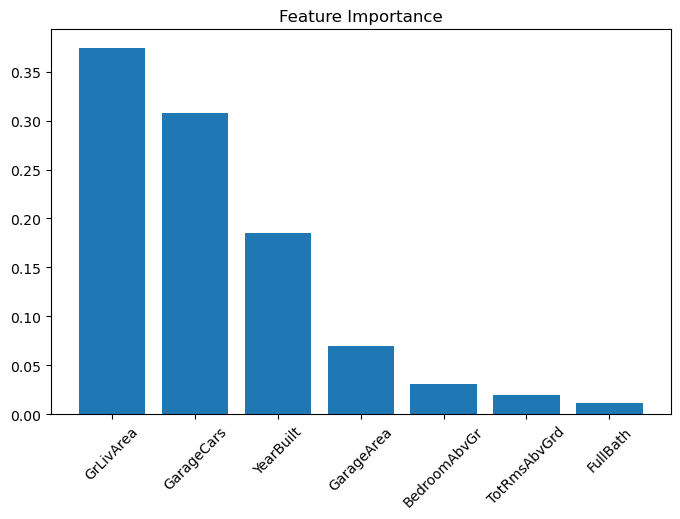

In [75]:
plt.figure(figsize=(8,5))
plt.bar(feature_importance["Feature"], feature_importance["Importance"])
plt.title("Feature Importance")
plt.xticks(rotation=45)
plt.show()
#mostra le variabili più influenti nell'oscillazione del prezzo

In [ ]:
## Conclusion

#The project analyzed housing data and built predictive models to estimate house prices.

#Random Forest performed better than Linear Regression, capturing more complex relationships between variables.

#Important features include:
#- living area
#- garage size
#- number of rooms